#### Thử nghiệm: GAM (Generalized Additive Model) cho model GIÁ CƠ BẢN

Theo đề xuất của mentor: thử model khác ngoài boosting tree. **GAM** là lựa chọn cân bằng giữa
hồi quy tuyến tính (đơn giản, dễ giải thích, nhưng cứng nhắc — chỉ vẽ được đường thẳng) và
boosting tree (linh hoạt, chính xác, nhưng như hộp đen khó giải thích).

**Công thức GAM:**
```
gia_du_doan = intercept + f1(quote_distance) + f2(quote_duration) + f3(gio_vn) + ... + f_dichvu(service_name)
```
Mỗi feature có **1 hàm cong riêng** (`f1`, `f2`...) được học tự động từ dữ liệu — không ép phải là
đường thẳng như hồi quy tuyến tính, nhưng vẫn **cộng dồn đơn giản** (không có tương tác phức tạp
giữa các feature như cây quyết định) → dễ vẽ ra xem, dễ giải thích cho người không chuyên.

So sánh trên cùng target `base_price`, cùng feature `B_NUM`, cùng test-set với GBM đã có.

**1. Nạp dữ liệu + mã hóa categorical (GAM cần số nguyên, không đọc string trực tiếp)**

In [1]:
import warnings, time
from pathlib import Path
import numpy as np, pandas as pd
from pygam import LinearGAM, s, f
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
warnings.filterwarnings("ignore")
pd.set_option("display.width", 220)

CAT = ["service_name", "pickup_location_name", "dropoff_location_name", "weather_main"]
B_NUM = ["quote_distance", "quote_duration", "gio_vn", "latest_observed_base",
         "history_60m_price_mean", "history_60m_price_std", "history_60m_price_slope_per_minute",
         "latest_observed_quote_distance", "latest_observed_quote_duration", "actual_observation_age_minutes"]

PREP = Path("../../data/hcm_train_ready.parquet")
assert PREP.exists(), "Chua co hcm_train_ready.parquet -> chay chuan_bi_du_lieu.ipynb truoc!"
COLS = list(dict.fromkeys(CAT + B_NUM + ["target_shown_price", "target_shown_multiplier",
        "latest_observed_price", "latest_observed_multiplier", "evaluation_month", "split"]))
COLS = [c for c in COLS if c != "latest_observed_base"]
df = pd.read_parquet(PREP, columns=COLS)
df["base_price"] = df.target_shown_price / df.target_shown_multiplier.clip(lower=0.1)
df["latest_observed_base"] = df.latest_observed_price / df.latest_observed_multiplier.clip(lower=0.1)

# Ma hoa categorical thanh so nguyen 0..k-1 (GAM f() can dang nay)
enc = OrdinalEncoder(dtype=np.int64)
df[CAT] = enc.fit_transform(df[CAT].astype(str))
print(f"Nap {len(df):,} dong | {len(CAT)} categorical (da ma hoa) + {len(B_NUM)} numeric")
for i, cname in enumerate(CAT):
    print(f"  {cname}: {len(enc.categories_[i])} nhom")

Nap 6,897,051 dong | 4 categorical (da ma hoa) + 10 numeric
  service_name: 2 nhom
  pickup_location_name: 3 nhom
  dropoff_location_name: 3 nhom
  weather_main: 4 nhom


**2. Định nghĩa cấu trúc GAM (setup ban đầu)**

- Mỗi feature số (`B_NUM`) → 1 hàm cong `s()` (smooth spline), `n_splines=12` (đủ uốn lượn, không quá phức tạp)
- Mỗi feature categorical (`CAT`) → 1 hệ số riêng cho từng nhóm `f()` (factor term)
- `lam` (lambda) = độ phạt làm mượt — GAM tự tối ưu qua `gridsearch` nếu cần, ở đây dùng mặc định trước, so sánh baseline

In [2]:
FEATS = B_NUM + CAT
col_idx = {name: i for i, name in enumerate(FEATS)}

def tao_gam_terms():
    terms = s(col_idx[B_NUM[0]], n_splines=12)
    for name in B_NUM[1:]:
        terms += s(col_idx[name], n_splines=12)
    for name in CAT:
        terms += f(col_idx[name])
    return terms

print(f"GAM formula: {len(B_NUM)} smooth term (s) + {len(CAT)} factor term (f) = {len(FEATS)} feature")
print("Vi du s(quote_distance): duong cong rieng cho quang duong, khong ep tuyen tinh")

GAM formula: 10 smooth term (s) + 4 factor term (f) = 14 feature
Vi du s(quote_distance): duong cong rieng cho quang duong, khong ep tuyen tinh


**3. Huấn luyện GAM theo từng tháng (log-target, giống pipeline GBM)**

In [3]:
thangs = sorted(df.evaluation_month.unique())
models, tests = {}, {}
print("Train theo thang:", thangs)
for th in thangs:
    sub = df[df.evaluation_month==th]
    tr = sub[sub.split=="train"]; te = sub[sub.split=="test"].copy()
    t0 = time.time()

    # pygam f() chi nhan gia tri categorical DA XUAT HIEN trong tap train.
    # Voi du lieu day du (~1,5M dong/thang) moi nhom deu co mat nen khong van de,
    # nhung neu giam FRAC thi nhom hiem (vd Mist ~1,8%) co the thieu -> loc va bao ro.
    hop_le = np.ones(len(te), dtype=bool)
    for cname in CAT:
        co_trong_train = set(tr[cname].unique())
        hop_le &= te[cname].isin(co_trong_train).values
    if not hop_le.all():
        bo = (~hop_le).sum()
        print(f"  [{th}] CANH BAO: bo {bo:,}/{len(te):,} dong test co nhom categorical "
              f"khong xuat hien trong train (thu tang FRAC o 00_chuan_bi_du_lieu.ipynb)")
        te = te[hop_le].copy()

    Xtr = tr[FEATS].values.astype(float)
    ytr = np.log(tr.base_price.values)
    gam = LinearGAM(tao_gam_terms(), max_iter=25).fit(Xtr, ytr)
    Xte = te[FEATS].values.astype(float)
    te["pred_gam"] = np.exp(gam.predict(Xte))
    models[th] = gam; tests[th] = te
    print(f"  [{th}] n_train={len(tr):,} n_test={len(te):,} | {time.time()-t0:.1f}s")

Train theo thang: ['2026-01', '2026-02', '2026-03']
  [2026-01] n_train=1,544,286 n_test=315,360 | 90.8s
  [2026-02] n_train=1,547,985 n_test=234,632 | 107.0s
  [2026-03] n_train=1,549,528 n_test=314,368 | 103.4s


**4. Kết quả — GAM vs GBM tốt nhất đã có**

In [4]:
def metrics(y, p):
    y, p = np.asarray(y), np.asarray(p)
    return dict(MAE=mean_absolute_error(y,p), RMSE=mean_squared_error(y,p)**.5,
                R2=r2_score(y,p), MAPE=np.mean(np.abs((y-p)/y))*100)

allte = pd.concat(tests.values())
rows = []
rows.append({"Model": "GAM", "Test-set": "TAT CA", "n": len(allte), **metrics(allte.base_price, allte.pred_gam)})
for th in thangs:
    dt = allte[allte.evaluation_month==th]
    rows.append({"Model": "GAM", "Test-set": th, "n": len(dt), **metrics(dt.base_price, dt.pred_gam)})
bang = pd.DataFrame(rows).round(4)
print("KET QUA GAM:"); display(bang)

pred_base = Path("../evaluation/pred_gia_co_ban.parquet")
if pred_base.exists():
    gb = pd.read_parquet(pred_base)
    print("\nDOI CHIEU voi GBM (cung target gia co ban):")
    for algo in sorted(gb.algo.unique()):
        d = gb[gb.algo==algo]
        mk = metrics(d.base_price, d.base_pred)
        mae_v = mk["MAE"]; r2_v = mk["R2"]; mape_v = mk["MAPE"]
        print(f"  {algo:10} MAE={mae_v:>8,.0f}  R2={r2_v:.4f}  MAPE={mape_v:.1f}%")
else:
    print("\n(Chua co pred_gia_co_ban.parquet -> chay train/01_train_gia_co_ban.ipynb de so sanh day du.)")

KET QUA GAM:


,Model,Test-set,n,MAE,RMSE,R2,MAPE
0,GAM,TAT CA,864360,15098.6836,19971.3921,0.6599,14.7772
1,GAM,2026-01,315360,15139.1907,20045.9958,0.6609,14.7927
2,GAM,2026-02,234632,15027.8600,19848.8430,0.6610,14.7378
3,GAM,2026-03,314368,15110.9087,19987.5917,0.6580,14.7909



DOI CHIEU voi GBM (base_pred, tung thuat toan da luu):
  HistGB     MAE=  15,032  R2=0.6563  MAPE=14.6%
  LightGBM   MAE=  15,038  R2=0.6562  MAPE=14.6%
  XGBoost    MAE=  15,045  R2=0.6556  MAPE=14.6%


**5. Ưu điểm riêng của GAM — xem đường cong từng feature (GBM không làm được trực tiếp như vậy)**

Đây là điểm mạnh nhất của GAM so với boosting tree: **vẽ được chính xác** hàm `f(feature)` mà model
học ra cho từng biến — không cần permutation importance/SHAP xấp xỉ như với cây.

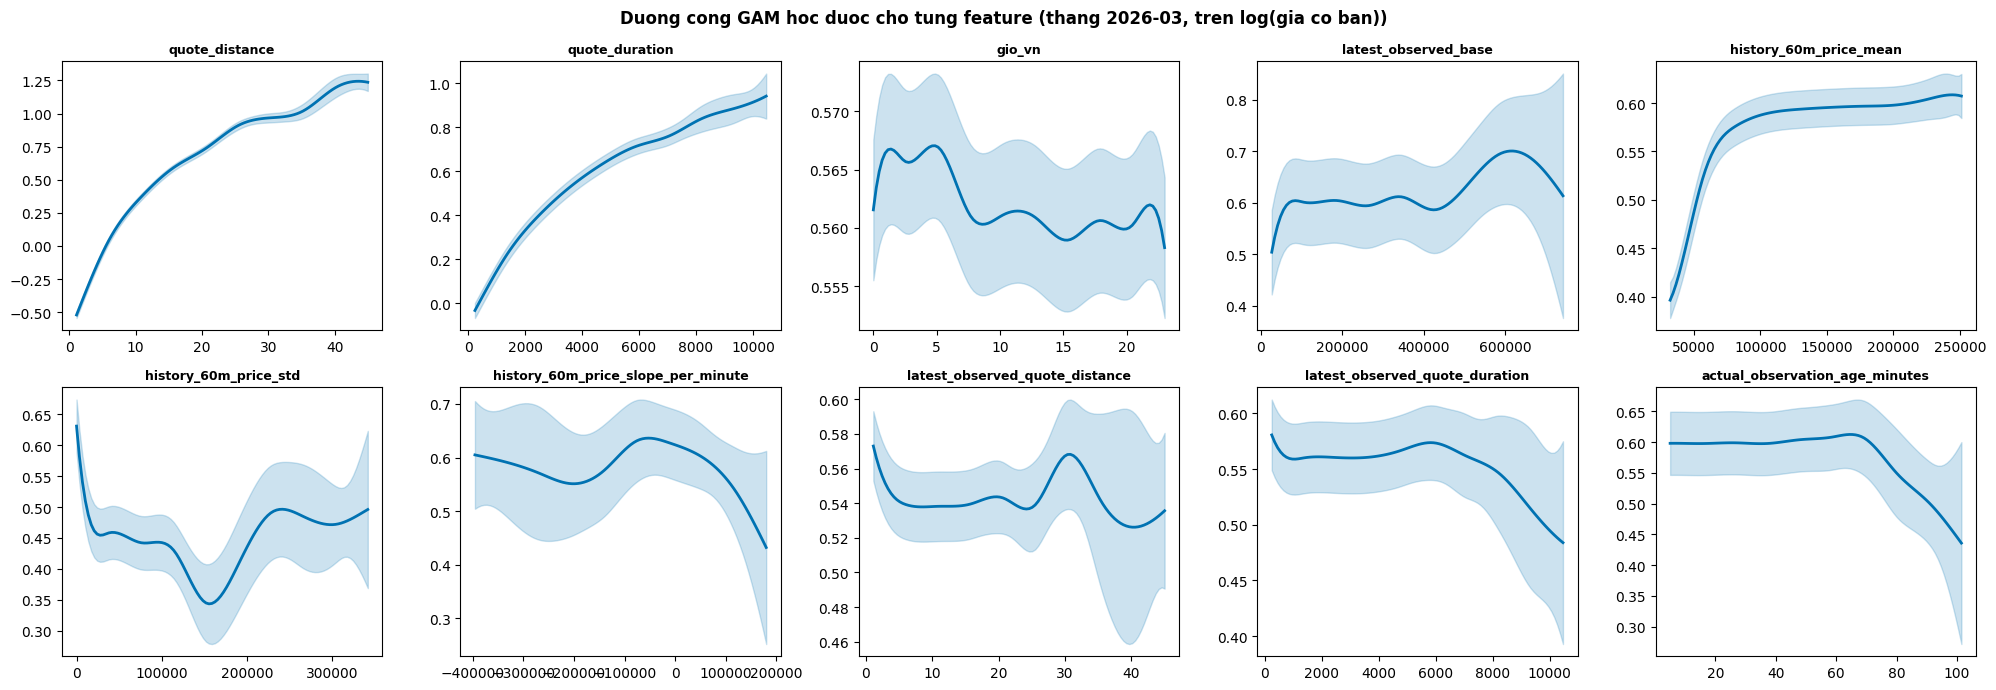

In [5]:
import matplotlib.pyplot as plt
gam_last = models[thangs[-1]]
fig, axes = plt.subplots(2, 5, figsize=(20, 7))
for i, name in enumerate(B_NUM):
    ax = axes.flat[i]
    XX = gam_last.generate_X_grid(term=i)
    pdep, confi = gam_last.partial_dependence(term=i, X=XX, width=0.95)
    ax.plot(XX[:, col_idx[name]], pdep, color="#0072B2", lw=2)
    ax.fill_between(XX[:, col_idx[name]], confi[:,0], confi[:,1], alpha=.2, color="#0072B2")
    ax.set_title(name, fontsize=9, fontweight="bold")
plt.suptitle(f"Duong cong GAM hoc duoc cho tung feature (thang {thangs[-1]}, tren log(gia co ban))", fontweight="bold")
plt.tight_layout(); plt.show()

**6. Mức ý nghĩa thống kê từng feature (p-value) — GAM có sẵn, GBM không có**

GAM xuất phát từ thống kê (statistics) nên cho luôn **p-value** kiểm định feature có ý nghĩa không —
GBM (machine learning thuần) không có khái niệm này.

In [6]:
print(gam_last.summary())

LinearGAM                                                                                                 
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                     95.8629
Link Function:                     IdentityLink Log Likelihood:                                 433397.592
Number of Samples:                      1549528 AIC:                                          -866601.4581
                                                AICc:                                         -866601.4459
                                                GCV:                                                0.0335
                                                Scale:                                              0.1829
                                                Pseudo R-Squared:                                    0.691
Feature Function                  Lam

**Kết luận**

- So MAE/R²/MAPE ở bước 4: nếu GAM **gần bằng** GBM → xác nhận quan hệ giữa feature và giá cơ bản
  chủ yếu là **cộng dồn đơn giản** (không cần tương tác phức tạp giữa các feature), và GAM đáng dùng
  vì **dễ giải thích hơn nhiều** cho cùng độ chính xác.
- Nếu GAM **kém hơn rõ rệt** → có tương tác quan trọng giữa các feature (VD: quãng đường × thời gian
  cùng lúc) mà GAM dạng cộng dồn thuần không bắt được, cần giữ boosting tree.
- Bước 5-6 là giá trị riêng của GAM: **nhìn thấy trực tiếp** hình dạng quan hệ (VD: giá tăng tuyến
  tính theo quãng đường hay có ngưỡng bão hòa?) và **biết chắc feature nào có ý nghĩa thống kê** —
  thứ boosting tree không cung cấp sẵn.